In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("C:\\Users\\Hp\\OneDrive\\Documents\\ola_cab_services.csv")
df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for Cancelling by Customer,Cancelled Rides by Driver,Reason for Cancelling by Driver,Incomplete Rides,Incomplete Rides Reason,Booking Value,Payment Method,Ride Distance,Driver Ratings,Customer Rating
0,28-01-2024,06:00:00,CNR1721175,Success,329258,Auto,Area-3,Area-2,5.42,18.46,...,NaN,0,NaN,0,NaN,868.06,Wallet,28.50,4.4,4.4
1,26-01-2024,03:00:00,CNR2871422,Cancelled by Driver,201414,Mini,Area-7,Area-6,NaN,NaN,...,NaN,1,The customer was coughing/sick,0,NaN,NaN,NaN,NaN,NaN,NaN
2,15-01-2024,16:00:00,CNR6875935,Cancelled by Driver,301629,Bike,Area-40,Area-24,NaN,NaN,...,NaN,1,Personal & Car related issues,0,NaN,NaN,NaN,NaN,NaN,NaN
3,02-01-2024,22:00:00,CNR6798834,Cancelled by Driver,319684,Prime Sedan,Area-11,Area-24,NaN,NaN,...,NaN,1,The customer was coughing/sick,0,NaN,NaN,NaN,NaN,NaN,NaN
4,30-01-2024,22:00:00,CNR9661713,Incomplete,330283,Bike,Area-41,Area-45,NaN,NaN,...,NaN,0,NaN,1,Other Issue,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,02-01-2024,00:00:00,CNR7299340,Success,454202,eBike,Area-39,Area-34,11.53,2.42,...,NaN,0,NaN,0,NaN,1217.43,Card,10.52,4.1,3.2
49995,27-01-2024,02:00:00,CNR0378586,Success,349873,Auto,Area-17,Area-21,5.56,9.05,...,NaN,0,NaN,0,NaN,1369.51,UPI,11.04,5.0,4.3
49996,17-01-2024,23:00:00,CNR2461856,Cancelled by Driver,880053,Auto,Area-37,Area-43,NaN,NaN,...,NaN,1,More than permitted people in there,0,NaN,NaN,NaN,NaN,NaN,NaN
49997,18-01-2024,22:00:00,CNR9524579,Success,752806,eBike,Area-48,Area-29,5.15,13.72,...,NaN,0,NaN,0,NaN,1930.49,UPI,14.49,3.1,4.5


In [13]:
cat_data=df[['Booking Status','Vehicle Type','Reason for Cancelling by Driver','Reason for Cancelling by Customer','Payment Method']]
cat_data

,Booking Status,Vehicle Type,Reason for Cancelling by Driver,Reason for Cancelling by Customer,Payment Method
0,Success,Auto,NaN,NaN,Wallet
1,Cancelled by Driver,Mini,The customer was coughing/sick,NaN,NaN
2,Cancelled by Driver,Bike,Personal & Car related issues,NaN,NaN
3,Cancelled by Driver,Prime Sedan,The customer was coughing/sick,NaN,NaN
4,Incomplete,Bike,NaN,NaN,NaN
...,...,...,...,...,...
49994,Success,eBike,NaN,NaN,Card
49995,Success,Auto,NaN,NaN,UPI
49996,Cancelled by Driver,Auto,More than permitted people in there,NaN,NaN
49997,Success,eBike,NaN,NaN,UPI


In [20]:
def cat_multi_analysis():
    for col in df:
        print(f"------------{col}Name ------------")
        print(df[col].value_counts().head())
        print(f"--------------------------")
        print()

In [21]:
cat_multi_analysis()

------------DateName ------------
Date
12-01-2024    1766
11-01-2024    1763
22-01-2024    1728
10-01-2024    1708
23-01-2024    1686
Name: count, dtype: int64
--------------------------

------------TimeName ------------
Time
00:00:00    2171
15:00:00    2171
12:00:00    2164
02:00:00    2140
17:00:00    2132
Name: count, dtype: int64
--------------------------

------------Booking IDName ------------
Booking ID
CNR1569898    2
CNR7174850    2
CNR5663879    2
CNR0443142    2
CNR9095846    2
Name: count, dtype: int64
--------------------------

------------Booking StatusName ------------
Booking Status
Success                  33484
Cancelled by Driver       9610
Cancelled by Customer     3799
Incomplete                3106
Name: count, dtype: int64
--------------------------

------------Customer IDName ------------
Customer ID
844154    3
476504    3
924373    3
580524    3
180400    3
Name: count, dtype: int64
--------------------------

------------Vehicle TypeName ------------
Veh

In [21]:
df.isnull().sum()
    


Date                                 0
Time                                 0
Booking ID                           0
Booking Status                       0
Customer ID                          0
Vehicle Type                         0
Pickup Location                      0
Drop Location                        0
Avg VTAT                             0
Avg CTAT                             0
Cancelled  by Customer               0
Reason for Cancelling by Customer    0
Cancelled Rides by Driver            0
Reason for Cancelling by Driver      0
Incomplete Rides                     0
Incomplete Rides Reason              0
Booking Value                        0
Payment Method                       0
Ride Distance                        0
Driver Ratings                       0
Customer Rating                      0
dtype: int64

In [16]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled  by Customer',
       'Reason for Cancelling by Customer', 'Cancelled Rides by Driver',
       'Reason for Cancelling by Driver', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Payment Method',
       'Ride Distance', 'Driver Ratings', 'Customer Rating'],
      dtype='object')

In [17]:
# M1] How do vehicle type and payment method together affect the average booking value?

df.groupby(['Vehicle Type', 'Payment Method'])['Booking Value'].mean()

Vehicle Type  Payment Method
Auto          Card              1015.945904
              Cash              1023.693918
              UPI               1018.657508
              Wallet            1010.729464
Bike          Card              1036.841315
              Cash              1018.270347
              UPI               1006.279655
              Wallet            1025.378195
Mini          Card              1017.670259
              Cash              1025.240340
              UPI               1019.978838
              Wallet            1034.161185
Prime Plus    Card              1000.299763
              Cash              1041.748786
              UPI               1021.004238
              Wallet            1023.415160
Prime SUV     Card               990.936784
              Cash              1034.251197
              UPI               1032.574425
              Wallet            1039.467873
Prime Sedan   Card               994.176463
              Cash              1039.401407
   

In [18]:
#M2] What is the average ride distance for each pickup and drop location pair?”
df.groupby(['Pickup Location', 'Drop Location'])['Ride Distance'].mean()

Pickup Location  Drop Location
Area-1           Area-1           26.121333
                 Area-10          26.620000
                 Area-11          21.958750
                 Area-12          24.925000
                 Area-13          22.586000
                                    ...    
Area-9           Area-50          21.197692
                 Area-6           26.473333
                 Area-7           19.610500
                 Area-8           24.978571
                 Area-9           30.445714
Name: Ride Distance, Length: 2500, dtype: float64

In [21]:
#M3] Which combination of vehicle type and pickup location has the highest number of rides?
df.groupby(['Vehicle Type', 'Pickup Location']).size()


Vehicle Type  Pickup Location
Auto          Area-1             149
              Area-10            136
              Area-11            141
              Area-12            129
              Area-13            131
                                ... 
eBike         Area-50            147
              Area-6             168
              Area-7             126
              Area-8             144
              Area-9             162
Length: 350, dtype: int64

<Axes: ylabel='Driver Ratings'>

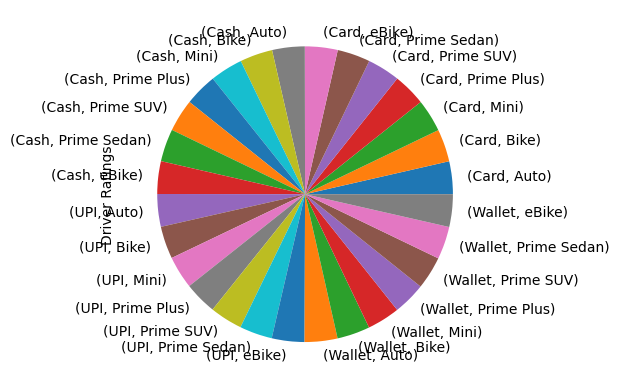

In [22]:
#M4] How do payment method and vehicle type impact driver ratings?
q4 = df.groupby(['Payment Method', 'Vehicle Type'])['Driver Ratings'].mean()
q4.plot(kind='pie')

<Axes: ylabel='Customer Rating'>

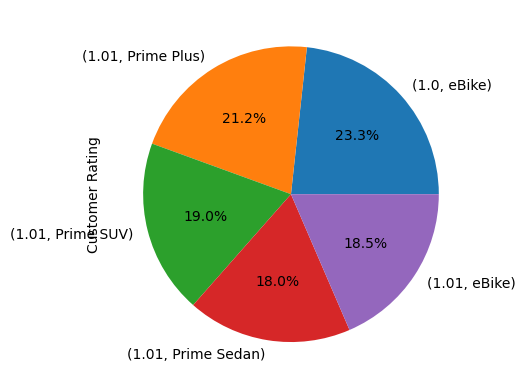

In [24]:
#M5] How does ride distance and vehicle type affect customer ratings?
df.groupby(['Ride Distance','Vehicle Type'])['Customer Rating'].mean().head().plot(kind='pie',autopct='%0.1f%%')

<Axes: xlabel='Vehicle Type,Drop Location'>

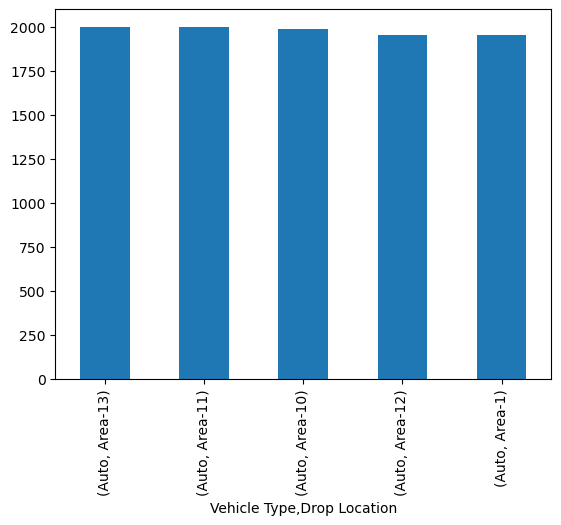

In [26]:
#M6] Which are top five vehicle type and drop location have the highest booking value?
df.groupby(['Vehicle Type','Drop Location'])['Booking Value'].max().head().sort_values(ascending=False).plot(kind='bar')

In [27]:
#M7] Which vehicle type & payment method combination gives the highest booking value?
df.groupby(['Vehicle Type','Payment Method'])['Booking Value'].mean().sort_values(ascending=False).head(1)

Vehicle Type  Payment Method
eBike         Wallet            1057.276962
Name: Booking Value, dtype: float64

In [28]:
#M8] On which date did Auto rides succeed the most?
df[(df['Vehicle Type']=='Auto') & (df['Booking Status']=='Success')]['Date'].mode()[0]

'12-01-2024'

In [31]:
#M9] Which vehicle type and pickup location pair shows longest average ride distance?
df.groupby(['Vehicle Type','Pickup Location'])['Ride Distance'].mean().sort_values(ascending=False).head(1)

Vehicle Type  Pickup Location
Auto          Area-44            29.60134
Name: Ride Distance, dtype: float64

In [32]:
#M10] How do ride distance and payment method together affect the average driver ratings?
df.groupby(['Ride Distance', 'Payment Method'])['Driver Ratings'].mean().head()

Ride Distance  Payment Method
1.00           UPI               4.900000
1.01           UPI               4.200000
               Wallet            3.966667
1.02           Card              4.500000
               Cash              3.400000
Name: Driver Ratings, dtype: float64

In [33]:
#M11] How do pickup and drop location pairs affect the total booking value?”
df.groupby(['Pickup Location','Drop Location'])['Booking Value'].mean().sort_values(ascending=False).head(1)

Pickup Location  Drop Location
Area-26          Area-33          1654.05
Name: Booking Value, dtype: float64

In [34]:
#M12] Which customer rating and vehicle type pair has the highest booking value?
df.groupby(['Customer Rating','Vehicle Type'])['Booking Value'].max().sort_values(ascending=False).head(1)

Customer Rating  Vehicle Type
3.0              Auto            2000.0
Name: Booking Value, dtype: float64

In [35]:
#M13] Which payment method and date pair recorded the most bookings?
df.groupby(['Date','Payment Method'])['Booking ID'].count().sort_values(ascending=False).head(1)

Date        Payment Method
09-01-2024  Cash              317
Name: Booking ID, dtype: int64

In [36]:
#M14] Which vehicle type and drop location pair gives the highest ride distance?
df.groupby(['Vehicle Type','Drop Location'])['Ride Distance'].mean().idxmax()

('Mini', 'Area-3')

In [37]:
#M15] Which pickup–drop pair has the shortest average ride distance?
df.groupby(['Pickup Location','Drop Location'])['Ride Distance'].mean().sort_values(ascending=True).head(1)

Pickup Location  Drop Location
Area-3           Area-24          10.498
Name: Ride Distance, dtype: float64

In [38]:
#M16] How do payment method and ride distance together affect the average booking value? 
df.groupby(['Payment Method', 'Ride Distance'])['Booking Value'].mean().head(1)

Payment Method  Ride Distance
Card            1.02             1998.18
Name: Booking Value, dtype: float64

In [39]:
#M17] Which vehicle type and payment method combination sees the highest average fare per km?
df.groupby(['Pickup Location','Drop Location','Vehicle Type'])['Booking Value'].mean().sort_values(ascending=False).head(1)

Pickup Location  Drop Location  Vehicle Type
Area-6           Area-14        Bike            1999.87
Name: Booking Value, dtype: float64

In [40]:
#M18]  Which pickup & drop location pair gives the lowest driver ratings?
df.groupby(['Pickup Location','Drop Location'])['Driver Ratings'].mean().sort_values().idxmin()

('Area-22', 'Area-32')

In [41]:
#M19] Which payment method is most common for each pickup location?
df.groupby(['Pickup Location','Payment Method']).size().sort_values(ascending=False).idxmax()

('Area-11', 'UPI')

In [42]:
#M20] Which vehicle type, payment method, and drop location combination had the most rides?
df.groupby(['Vehicle Type','Payment Method','Drop Location'])['Booking ID'].count().sort_values(ascending=False).head(1)

Vehicle Type  Payment Method  Drop Location
Bike          UPI             Area-39          40
Name: Booking ID, dtype: int64

In [43]:
#M21] Which payment method and day combination recorded the highest revenue?
df.groupby(['Date','Payment Method'])['Booking Value'].sum().sort_values(ascending=False).head(1)

Date        Payment Method
09-01-2024  Cash              328833.54
Name: Booking Value, dtype: float64

In [44]:
#M22] Which pickup–drop–vehicle type combination gives the longest average ride distance?
df.groupby(["Vehicle Type", "Driver Ratings"])['Ride Distance'].mean().reset_index().sort_values(by='Ride Distance', ascending=False).head(1)

,Vehicle Type,Driver Ratings,Ride Distance
36,Bike,4.5,28.493133


In [45]:
#M24] Which customer ID and vehicle type pair has the highest number of successful rides?
df[df['Booking Status']=='Success'].groupby(['Customer ID','Vehicle Type'])['Booking ID'].count().sort_values(ascending=False).head(1)

Customer ID  Vehicle Type
380789       Prime Plus      2
Name: Booking ID, dtype: int64

In [46]:
#M25] Which drop location and vehicle type get the most 5-star customer ratings?
df[df['Customer Rating']==5].groupby(['Drop Location','Vehicle Type'])['Booking ID'].count().idxmax(), df[df['Customer Rating']==5].groupby(['Drop Location','Vehicle Type'])['Booking ID'].count().max()

(('Area-17', 'Prime SUV'), 7)

In [47]:
#M26] Which pickup & drop location pair gives the lowest driver ratings?
df.groupby(['Pickup Location','Drop Location'])['Driver Ratings'].mean().sort_values().idxmin()

('Area-22', 'Area-32')

In [48]:
#M27] Which vehicle type and date combination has the maximum revenue?
df.groupby(['Date','Vehicle Type'])['Booking Value'].sum().sort_values(ascending=False).head(1)

Date        Vehicle Type
11-01-2024  eBike           194642.88
Name: Booking Value, dtype: float64

In [49]:
#M28] Which pickup–drop pair has the shortest average ride distance?
df.groupby(['Pickup Location','Drop Location'])['Ride Distance'].mean().sort_values().head(1)

Pickup Location  Drop Location
Area-3           Area-24          10.498
Name: Ride Distance, dtype: float64

In [50]:
#M29] Which vehicle type and drop location pair gives the highest ride distance?
df.groupby(['Vehicle Type','Drop Location'])['Ride Distance'].mean().sort_values(ascending=False).head(1)

Vehicle Type  Drop Location
Mini          Area-3           29.092128
Name: Ride Distance, dtype: float64

In [51]:
#M30] From which pickup location, with which vehicle type, and using which payment method do customers spend the most money?"
df.groupby(['Pickup Location','Vehicle Type','Payment Method'])['Booking Value'].sum().sort_values(ascending=False).idxmax()

('Area-44', 'Auto', 'Card')

In [16]:
#M31]. Which Drop Location and Vehicle Type combination has the maximum count of incomplete rides?
df[df["Booking Status"]=="Incomplete"].groupby(["Drop Location","Vehicle Type"])["Booking ID"].count().reset_index().sort_values(by="Booking ID",ascending=False).head(1)


,Drop Location,Vehicle Type,Booking ID
182,Area-33,Auto,19


In [54]:
#M32] Which Vehicle Type and Driver Rating combination gives the longest average ride distance?
df.groupby(["Vehicle Type","Driver Ratings"])["Ride Distance"].mean().reset_index().sort_values(by="Ride Distance", ascending=False).head(1)


,Vehicle Type,Driver Ratings,Ride Distance
36,Bike,4.5,28.493133


In [55]:
#M33] Which Date and Payment Method combination recorded the highest number of successful rides?
df[df["Booking Status"]=="Success"].groupby(["Date","Payment Method"])["Booking ID"].count().reset_index().sort_values(by="Booking ID", ascending=False).head(1)


,Date,Payment Method,Booking ID
33,09-01-2024,Cash,317


In [56]:
#M34]Which Pickup Location and Vehicle Type combination has the lowest average customer rating?
df.groupby(["Pickup Location","Vehicle Type"])["Customer Rating"].mean().reset_index().sort_values(by="Customer Rating", ascending=True).head(1)


,Pickup Location,Vehicle Type,Customer Rating
251,Area-41,eBike,3.829412


In [57]:
#M35]Which Vehicle Type and Payment Method combination has the highest average ride distance?
df.groupby(["Vehicle Type","Payment Method"])["Ride Distance"].mean().reset_index().sort_values(by="Ride Distance",ascending=False).head(1)


,Vehicle Type,Payment Method,Ride Distance
3,Auto,Wallet,26.152185


In [58]:
#M36] Which Pickup–Drop combination generated the maximum total booking value?
df.groupby(["Pickup Location","Drop Location"])["Booking Value"].sum().reset_index().sort_values(by="Booking Value",ascending=False).head(1)


,Pickup Location,Drop Location,Booking Value
480,Area-18,Area-37,30103.98


In [59]:
#M37] Which Date and Vehicle Type combination recorded the highest revenue?
df.groupby(["Date","Vehicle Type"])["Booking Value"].sum().reset_index().sort_values(by="Booking Value",ascending=False).head(1)


,Date,Vehicle Type,Booking Value
76,11-01-2024,eBike,194642.88


In [60]:
#M38]Which Driver Rating and Customer Rating combo gives the highest average booking value?
df.groupby(["Driver Ratings","Customer Rating"])["Booking Value"].mean().reset_index().sort_values(by="Booking Value",ascending=False).head(1)


,Driver Ratings,Customer Rating,Booking Value
29,3.1,3.8,1280.120704


In [61]:
#M39] Which Vehicle Type and Drop Location combination has the longest average ride distance?
df.groupby(["Vehicle Type","Drop Location"])["Ride Distance"].mean().reset_index().sort_values(by="Ride Distance",ascending=False).head(1)


,Vehicle Type,Drop Location,Ride Distance
122,Mini,Area-3,29.092128


In [62]:
#M40]Which Pickup Location and Payment Method combination earned the highest revenue?
df.groupby(["Pickup Location","Payment Method"])["Booking Value"].sum().reset_index().sort_values(by="Booking Value",ascending=False).head(1)


,Pickup Location,Payment Method,Booking Value
129,Area-39,Cash,210570.44


In [4]:
#M41] Which Date and Vehicle Type combination has the most incomplete rides?
df[df["Booking Status"]=="Incomplete"].groupby(["Date","Vehicle Type"])["Booking ID"].count().reset_index().sort_values(by="Booking ID",ascending=False).head(1)


,Date,Vehicle Type,Booking ID
64,10-01-2024,Bike,32


In [5]:
#M42] Which Payment Method and Vehicle Type combination has the highest customer rating?
df.groupby(["Payment Method","Vehicle Type"])["Customer Rating"].mean().reset_index().sort_values(by="Customer Rating",ascending=False).head(1)


,Payment Method,Vehicle Type,Customer Rating
4,Card,Prime SUV,4.036555


In [6]:
#M43] Which Pickup Location and Vehicle Type combination has the most driver cancellations?
df[df["Booking Status"]=="Cancelled by Driver"].groupby(["Pickup Location","Vehicle Type"])["Booking ID"].count().reset_index().sort_values(by="Booking ID",ascending=False).head(1)


,Pickup Location,Vehicle Type,Booking ID
270,Area-44,Prime SUV,44


In [7]:
#M44] Which Date and Payment Method combination gives the highest average booking value?
df.groupby(["Date","Payment Method"])["Booking Value"].mean().reset_index().sort_values(by="Booking Value",ascending=False).head(1)


,Date,Payment Method,Booking Value
30,08-01-2024,UPI,1147.269778


In [8]:
#M45] Which Pickup Location, Drop Location, and Vehicle Type combination generates the highest revenue?
df.groupby(["Pickup Location","Drop Location","Vehicle Type"])["Booking Value"].sum().reset_index().sort_values(by="Booking Value",ascending=False).head(1)


,Pickup Location,Drop Location,Vehicle Type,Booking Value
1646,Area-13,Area-8,Bike,11456.02


In [10]:
#M46] Which Vehicle Type and Payment Method combination has the highest number of successful rides?
df[df["Booking Status"]=="Success"].groupby(["Vehicle Type","Payment Method"])["Booking ID"].count().reset_index().sort_values(by="Booking ID",ascending=False).head(1)


,Vehicle Type,Payment Method,Booking ID
9,Mini,Cash,1263


In [11]:
#M47] Which Pickup Location and Date combination has the highest total booking value?
df.groupby(["Pickup Location","Date"])["Booking Value"].sum().reset_index().sort_values(by="Booking Value",ascending=False).head(1)


,Pickup Location,Date,Booking Value
106,Area-12,14-01-2024,40598.91


In [5]:
#M48] Which Drop Location and Payment Method combination yields the longest average ride distance?
df.groupby(["Drop Location","Payment Method"])["Ride Distance"].mean().reset_index().sort_values(by="Ride Distance",ascending=False).head(1)


,Drop Location,Payment Method,Ride Distance
187,Area-6,Wallet,28.083942


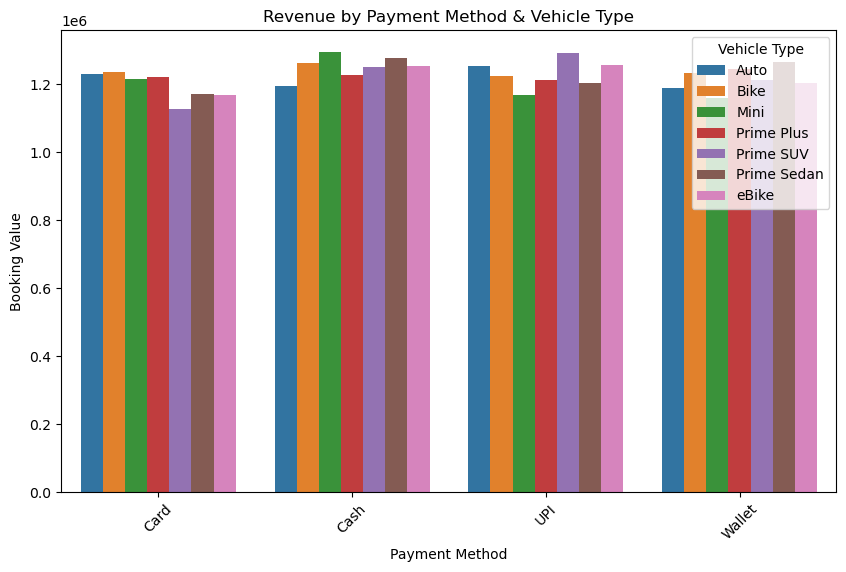

In [42]:
#M49] Which Payment Method and Vehicle Type combination generates the highest total revenue?

q1 = df.groupby(["Payment Method","Vehicle Type"])["Booking Value"].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=q1, x="Payment Method", y="Booking Value", hue="Vehicle Type")
plt.title("Revenue by Payment Method & Vehicle Type")
plt.xticks(rotation=45)
plt.show()


In [10]:
#M50] Which Pickup–Drop pair and Payment Method generates the highest customer ratings on average?
df.groupby(["Pickup Location", "Drop Location", "Payment Method"])["Customer Rating"].mean().reset_index().sort_values(by="Customer Rating", ascending=False).head(1)

,Pickup Location,Drop Location,Payment Method,Customer Rating
8110,Area-48,Area-15,Card,5.0


In [14]:
m51 = df.groupby("Vehicle Type")["Ride Distance"].mean().reset_index()
m51 = m51.sort_values(by="Ride Distance", ascending=False).head()
print(m51)


  Vehicle Type  Ride Distance
0         Auto      25.740017
2         Mini      25.583826
5  Prime Sedan      25.509234
1         Bike      25.411473
4    Prime SUV      25.396211


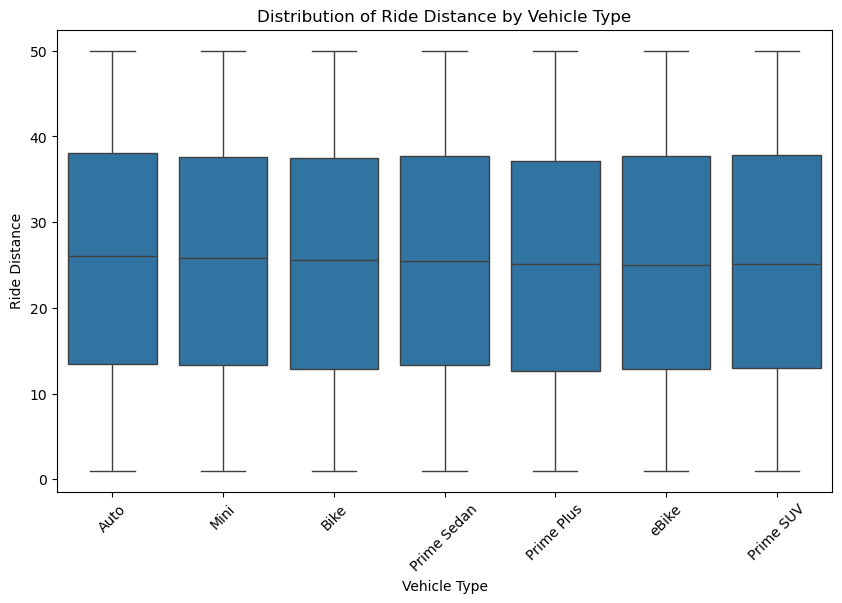

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Vehicle Type", y="Ride Distance")
plt.title("Distribution of Ride Distance by Vehicle Type")
plt.xticks(rotation=45)
plt.show()



In [4]:
for col in df.select_dtypes(include=["int64","float64"]).columns:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outlier_count = df[(df[col] < (Q1 - 1.5*IQR)) | (df[col] > (Q3 + 1.5*IQR))].shape[0]
    print(f"{col}: {outlier_count} outliers")


Customer ID: 0 outliers
Avg VTAT: 0 outliers
Avg CTAT: 0 outliers
Cancelled  by Customer: 3799 outliers
Cancelled Rides by Driver: 9610 outliers
Incomplete Rides: 3106 outliers
Booking Value: 0 outliers
Ride Distance: 0 outliers
Driver Ratings: 0 outliers
Customer Rating: 0 outliers


In [5]:
for col in df.select_dtypes(include="object").columns:
    counts = df[col].value_counts(normalize=True) * 100
    rare = counts[counts < 1]   # categories appearing in less than 1% of rows
    if not rare.empty:
        print(f"\nColumn: {col}")
        print(rare)



Column: Date
Date
31-01-2024    0.132003
Name: proportion, dtype: float64

Column: Booking ID
Booking ID
CNR1569898    0.004
CNR7174850    0.004
CNR5663879    0.004
CNR0443142    0.004
CNR9095846    0.004
              ...  
CNR4360421    0.002
CNR7299340    0.002
CNR2461856    0.002
CNR9524579    0.002
CNR2871422    0.002
Name: proportion, Length: 49866, dtype: float64


In [6]:
rare_summary = {col: sum(df[col].value_counts(normalize=True) < 0.01) for col in df.select_dtypes(include="object").columns}
pd.DataFrame(list(rare_summary.items()), columns=["Column","Rare_Category_Count"]).sort_values("Rare_Category_Count",ascending=False)


,Column,Rare_Category_Count
2,Booking ID,49866
0,Date,1
1,Time,0
3,Booking Status,0
4,Vehicle Type,0
5,Pickup Location,0
6,Drop Location,0
7,Reason for Cancelling by Customer,0
8,Reason for Cancelling by Driver,0
9,Incomplete Rides Reason,0
